## 1. Import Libraries

We import the libraries needed for data preparation, K-Means clustering, and cluster evaluation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load the Processed Dataset

We load the preprocessed dataset created in the previous notebook. The data has already been cleaned, missing values have been imputed, and selected outliers have been capped.


In [2]:
df = pd.read_csv("../data/processed/diabetes_preprocessed.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [3]:
df.shape

(768, 8)

## 3. Select Clinical Variables

We select the clinical variables that will be used by K-Means. The index column is excluded because it does not contain clinical information.


In [4]:
clinical_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[clinical_columns]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


In [6]:
X.shape

(768, 8)

## 4. Standardize the Features

We standardize the clinical variables using `StandardScaler` so that they have a comparable scale before applying K-Means.


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [12]:
scaled_summary = pd.DataFrame(
    {
        "Mean" : X_scaled.mean(axis=0),
        "Std" : X_scaled.std(axis=0)
    },
    index = clinical_columns
)

scaled_summary

,Mean,Std
Pregnancies,-6.476301e-17,1.0
Glucose,2.474872e-16,1.0
BloodPressure,-4.625929e-18,1.0
SkinThickness,-5.637851e-16,1.0
Insulin,-1.110223e-16,1.0
BMI,-4.487151e-16,1.0
DiabetesPedigreeFunction,2.220446e-16,1.0
Age,1.931325e-16,1.0


## 5. Test Different Values of K

We test different numbers of clusters and calculate the inertia for each value of K. These values will be used to apply the Elbow Method.


In [13]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)

In [14]:
print(inertias)

[4740.933503445804, 4112.998678429577, 3747.9864000083617, 3511.5427321396674, 3306.87919981155, 3094.712196512597, 2959.5548282661066, 2842.260127669851, 2730.630853695333]


## 6. Elbow Method

We visualize the inertia for different values of K. The elbow corresponds to the point where increasing K produces a smaller improvement in inertia.


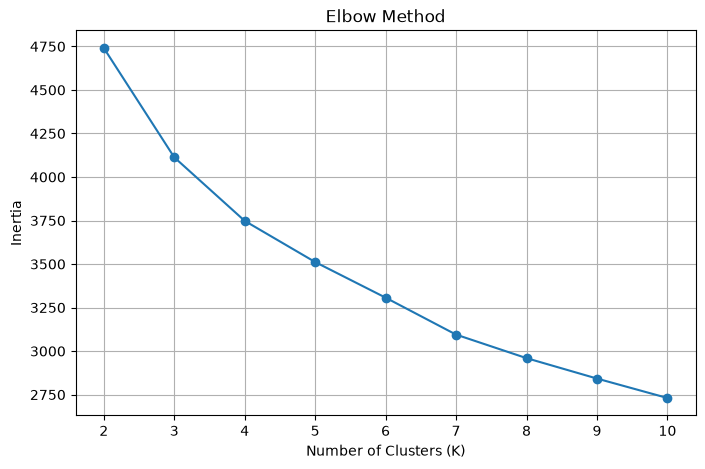

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

## 7. Silhouette Score

We calculate the Silhouette Score for different values of K to evaluate the quality of the clusters.

A higher Silhouette Score generally indicates that the clusters are more compact and better separated.


In [16]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

silhouette_scores

[0.22476647780476267,
 0.21021051738410557,
 0.16366059613777947,
 0.1525901234400384,
 0.1648495544872578,
 0.16476309596397273,
 0.1630926928222106,
 0.1733251329152412,
 0.17150594488940366]

## 8. Silhouette Score Visualization

We visualize the Silhouette Score for different values of K to compare the quality of the clustering solutions.


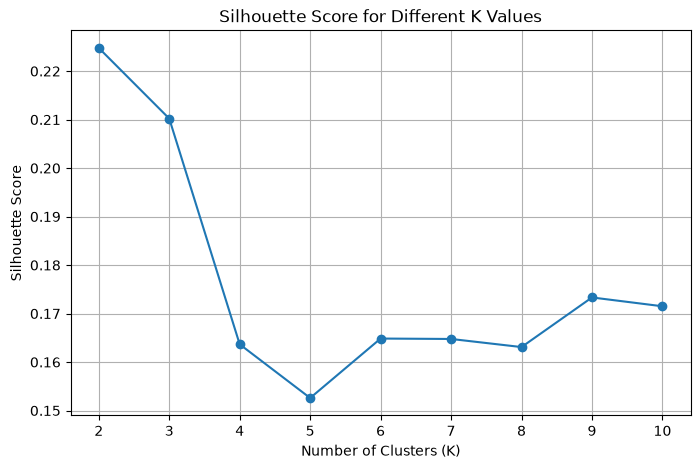

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

## 9. Compare K-Means Solutions

We compare K=2, K=3, and K=4 to understand how the number of clusters affects the patient profiles.

For each value of K, we examine the cluster sizes and the mean values of the clinical variables.


In [18]:
results = {}

for k in [2, 3, 4]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    df_temp = df.copy()
    df_temp["Cluster"] = labels
    
    results[k] = df_temp

    print(f"\nK = {k}")
    print("Cluster sizes:")
    print(df_temp["Cluster"].value_counts().sort_index())


K = 2
Cluster sizes:
Cluster
0    428
1    340
Name: count, dtype: int64

K = 3
Cluster sizes:
Cluster
0    347
1    200
2    221
Name: count, dtype: int64

K = 4
Cluster sizes:
Cluster
0    114
1    202
2    192
3    260
Name: count, dtype: int64


In [25]:
for k, df_temp in results.items():
    print(f"\n===== K = {k} =====")
    
    profile = (
        df_temp.groupby("Cluster")[clinical_columns]
        .mean()
        .round(2)
    )
    
    display(profile)


===== K = 2 =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.45,106.62,67.47,25.30,105.97,29.88,0.43,27.07
1,5.60,140.45,78.58,33.46,202.16,35.63,0.53,41.01



===== K = 3 =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.49,105.92,66.99,22.93,101.68,28.37,0.42,26.85
1,1.99,132.46,75.55,37.24,187.74,39.14,0.58,28.88
2,7.65,136.36,77.99,30.77,186.70,32.74,0.46,47.21



===== K = 4 =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.69,158.36,76.97,36.41,261.21,39.96,0.65,32.08
1,7.91,132.12,78.08,30.10,177.80,31.91,0.45,47.21
2,2.21,109.36,72.56,34.36,118.87,36.22,0.45,28.56
3,2.40,106.33,65.83,20.68,98.36,26.73,0.42,26.35


## 10. Train the Final K-Means Model

We use K=3 to train the final K-Means model and assign each patient to a cluster.


In [28]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_scaled)

## 11. Add Cluster Labels

We add the cluster assigned by K-Means to each patient.

Each patient receives a cluster label: 0, 1, or 2.


In [29]:
df_clustered = df.copy()

df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Cluster
0,6.0,148.0,72.0,35.0,264.8,33.6,0.627,50.0,2
1,1.0,85.0,66.0,29.0,65.2,26.6,0.351,31.0,0
2,8.0,183.0,64.0,30.6,198.2,23.3,0.672,32.0,2
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [30]:
df_clustered["Cluster"].value_counts().sort_index()

Cluster
0    347
1    200
2    221
Name: count, dtype: int64

In [31]:
cluster_profile = (
    df_clustered
    .groupby("Cluster")[clinical_columns]
    .mean()
    .round(2)
)

cluster_profile

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster,,,,,,,,
0,2.49,105.92,66.99,22.93,101.68,28.37,0.42,26.85
1,1.99,132.46,75.55,37.24,187.74,39.14,0.58,28.88
2,7.65,136.36,77.99,30.77,186.70,32.74,0.46,47.21


## Apply the Project's High-Risk Criteria

The project defines a cluster as **high-risk** when its average profile meets the following three criteria:

- **Glucose > 126**
- **BMI > 30**
- **DiabetesPedigreeFunction > 0.5**

We compare the average values of each cluster with these thresholds.

- **Cluster 0:** Glucose = 105.92, BMI = 28.37, DPF = 0.42 → does not meet the criteria.
- **Cluster 1:** Glucose = 132.46, BMI = 39.14, DPF = 0.58 → meets all three criteria.
- **Cluster 2:** Glucose = 136.36, BMI = 32.74, DPF = 0.46 → does not meet all three criteria.

Therefore, **Cluster 1 is considered high-risk according to the project's criteria**, while Cluster 0 and Cluster 2 are not.

The project uses two risk categories:
- **High Risk:** cluster meets all three high-risk criteria.
- **Low Risk:** cluster does not meet all three criteria.

This is a **cluster-based risk profile**, not a clinical diagnosis.

## 12. Create Risk Category

We assign a risk category to each patient based on the cluster identified by K-Means.

Cluster 1 meets all three project criteria: Glucose > 126, BMI > 30, and DiabetesPedigreeFunction > 0.5.

Therefore:

* Cluster 1 → High Risk
* Cluster 0 and Cluster 2 → Low Risk

This is a cluster-based risk profile, not a clinical diagnosis.


In [32]:
df_clustered["risk_category"] = df_clustered["Cluster"].map({
    0: "Low Risk",
    1: "High Risk",
    2: "Low Risk"
})

In [33]:
df_clustered[["Cluster", "risk_category"]].head(10)

,Cluster,risk_category
0,2,Low Risk
1,0,Low Risk
2,2,Low Risk
3,0,Low Risk
4,1,High Risk
5,0,Low Risk
6,0,Low Risk
7,2,Low Risk
8,2,Low Risk
9,2,Low Risk


In [34]:
df_clustered["risk_category"].value_counts()

risk_category
Low Risk     568
High Risk    200
Name: count, dtype: int64